# Exploration des données — Porto Taxi (ECML/PKDD 2015)

Analyse exploratoire calculée en **une seule passe streaming** sur l'intégralité
de `train.csv` (~2 Go) par [`eda.py`](eda.py). Ce notebook ne relit pas le CSV :
il charge les agrégats mis en cache (`eda_cache.npz` + `eda_cache.json`) et les
visualise.

Objectif : vérifier que les données ont assez de **structure, de diversité et de
propreté** pour qu'un apprentissage de représentations de trajectoires soit
envisageable. On décrit ici uniquement les propriétés des données — aucune
décision de modèle ni de préprocessing.

**Axes couverts**
1. Couverture spatiale & densité
2. Géométrie des trajectoires
3. Qualité des données
4. Temporel & métadonnées

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

npz = np.load("eda_cache.npz")
n_points     = npz["n_points"]
length_km    = npz["length_km"]
max_seg_km   = npz["max_seg_km"]
dup_frac     = npz["dup_frac"]
n_jumps      = npz["n_jumps"]
duration_min = npz["duration_min"]
grid         = npz["grid"]
trips_per_taxi = npz["trips_per_taxi"]

with open("eda_cache.json", encoding="utf-8") as f:
    S = json.load(f)

print(f"Lignes lues        : {S['n_rows']:,}")
print(f"Trajectoires valides: {S['n_valid']:,}")
print(f"Taxis distincts     : {S['n_taxis']:,}")
print(f"Temps de calcul     : {S['elapsed_s']} s")

Lignes lues        : 1,710,670
Trajectoires valides: 1,674,160
Taxis distincts     : 448
Temps de calcul     : 187.8 s


## Axe 3 — Qualité des données

On regarde d'abord ce qu'on **jette** et le niveau de bruit dans ce qu'on garde.
Un dataset trop bruité (sauts GPS, points figés) dégrade tout apprentissage.

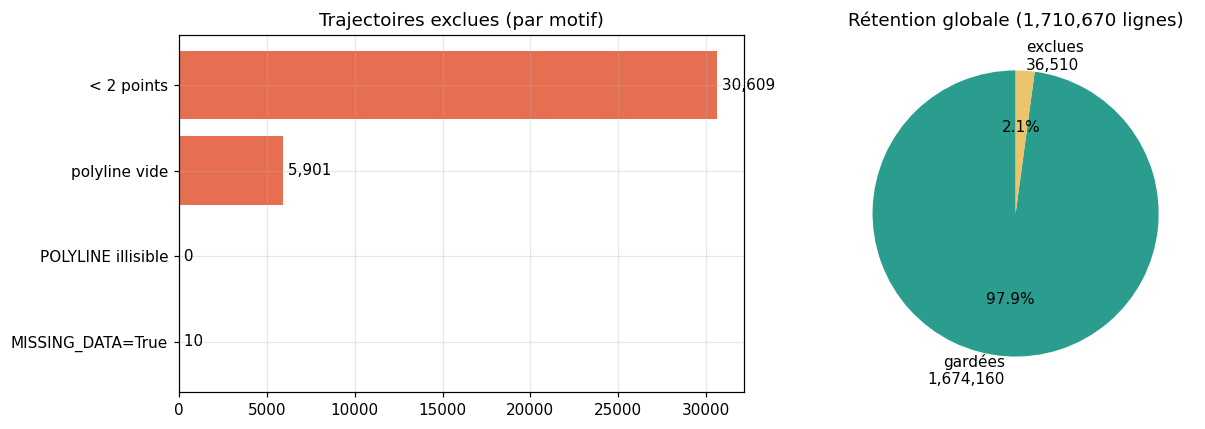

Taux de rétention : 97.87 %


In [2]:
reasons = {
    "MISSING_DATA=True": S["n_missing_flag"],
    "POLYLINE illisible": S["n_parse_error"],
    "polyline vide": S["n_empty"],
    "< 2 points": S["n_too_short"],
}
valid = S["n_valid"]; total = S["n_rows"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

labels = list(reasons.keys()); vals = list(reasons.values())
ax[0].barh(labels, vals, color="#e76f51")
ax[0].set_title("Trajectoires exclues (par motif)")
for i, v in enumerate(vals):
    ax[0].text(v, i, f" {v:,}", va="center")

kept = valid; dropped = total - valid
ax[1].pie([kept, dropped], labels=[f"gardées\n{kept:,}", f"exclues\n{dropped:,}"],
          autopct="%1.1f%%", colors=["#2a9d8f", "#e9c46a"], startangle=90)
ax[1].set_title(f"Rétention globale ({total:,} lignes)")
plt.tight_layout(); plt.show()

print(f"Taux de rétention : {100*valid/total:.2f} %")

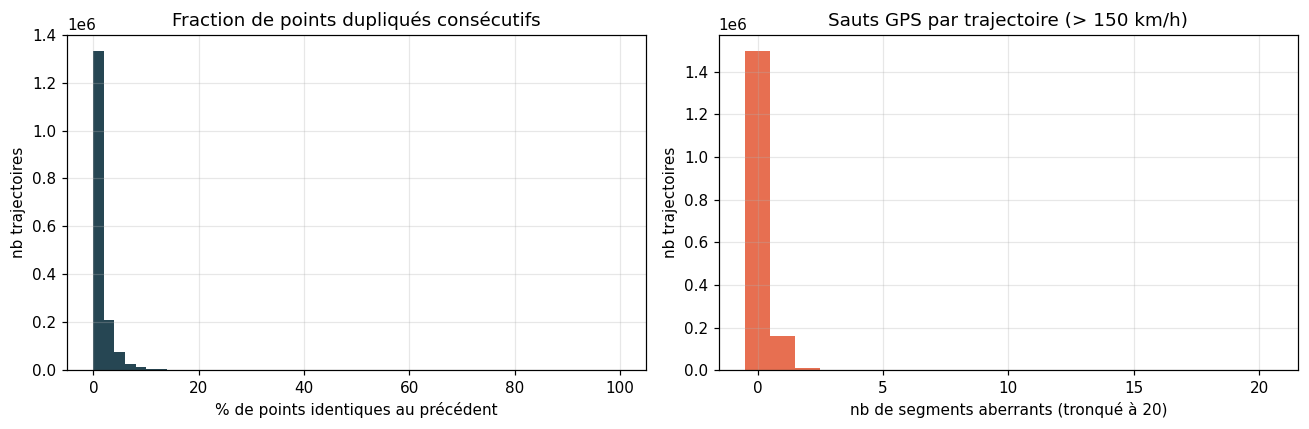

Trajectoires avec >=1 saut GPS : 174,912 (10.4 %)
Fraction moyenne de points dupliqués : 1.04 %
Plus long segment observé : 1130.7 km


In [3]:
# Bruit dans les trajectoires gardées
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(dup_frac * 100, bins=50, color="#264653")
ax[0].set_title("Fraction de points dupliqués consécutifs")
ax[0].set_xlabel("% de points identiques au précédent")
ax[0].set_ylabel("nb trajectoires")

# n_jumps : segments > seuil de vitesse (sauts GPS)
jump_speed = S["jump_speed_kmh"]
has_jump = np.count_nonzero(n_jumps > 0)
ax[1].hist(np.clip(n_jumps, 0, 20), bins=range(0, 22), color="#e76f51", align="left")
ax[1].set_title(f"Sauts GPS par trajectoire (> {jump_speed:.0f} km/h)")
ax[1].set_xlabel("nb de segments aberrants (tronqué à 20)")
ax[1].set_ylabel("nb trajectoires")
plt.tight_layout(); plt.show()

print(f"Trajectoires avec >=1 saut GPS : {has_jump:,} "
      f"({100*has_jump/len(n_jumps):.1f} %)")
print(f"Fraction moyenne de points dupliqués : {dup_frac.mean()*100:.2f} %")
print(f"Plus long segment observé : {max_seg_km.max():.1f} km")

## Axe 2 — Géométrie des trajectoires

Longueur (en points, en durée, en distance) et régularité. C'est ici qu'on juge
la **richesse structurelle** des séquences : trop courtes = peu à apprendre,
distribution trop plate = peu de variété.

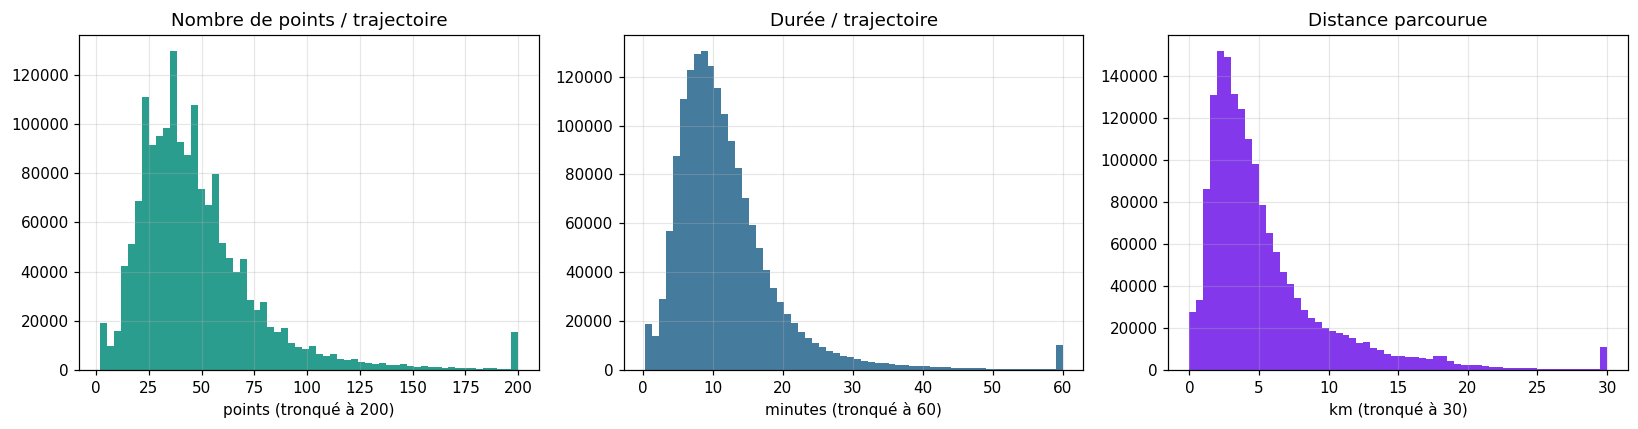

Nb points  : min=2.0  p5=15.0  p25=29.0  médiane=42.0  p75=59.0  p95=103.0  p99=191.0  max=3881.0 
Durée      : min=0.2  p5=3.5  p25=7.0  médiane=10.2  p75=14.5  p95=25.5  p99=47.5  max=970.0 min
Distance   : min=0.0  p5=1.2  p25=2.5  médiane=4.0  p75=6.6  p95=15.0  p99=24.3  max=1229.3 km


In [4]:
def describe(a, unit=""):
    qs = np.percentile(a, [5, 25, 50, 75, 95, 99])
    return (f"min={a.min():.1f}  p5={qs[0]:.1f}  p25={qs[1]:.1f}  "
            f"médiane={qs[2]:.1f}  p75={qs[3]:.1f}  p95={qs[4]:.1f}  "
            f"p99={qs[5]:.1f}  max={a.max():.1f} {unit}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(np.clip(n_points, 0, 200), bins=60, color="#2a9d8f")
ax[0].set_title("Nombre de points / trajectoire")
ax[0].set_xlabel("points (tronqué à 200)")

ax[1].hist(np.clip(duration_min, 0, 60), bins=60, color="#457b9d")
ax[1].set_title("Durée / trajectoire")
ax[1].set_xlabel("minutes (tronqué à 60)")

ax[2].hist(np.clip(length_km, 0, 30), bins=60, color="#8338ec")
ax[2].set_title("Distance parcourue")
ax[2].set_xlabel("km (tronqué à 30)")
plt.tight_layout(); plt.show()

print("Nb points  :", describe(n_points))
print("Durée      :", describe(duration_min, "min"))
print("Distance   :", describe(length_km, "km"))

## Axe 1 — Couverture spatiale & densité

Où les taxis roulent réellement. Le *bounding box* donne l'emprise ; la heatmap
(échelle log) révèle la concentration centre-ville vs périphérie.

Bounding box réel :
  longitude ∈ [-8.86842, -8.000001]
  latitude  ∈ [40.500018, 41.799987]


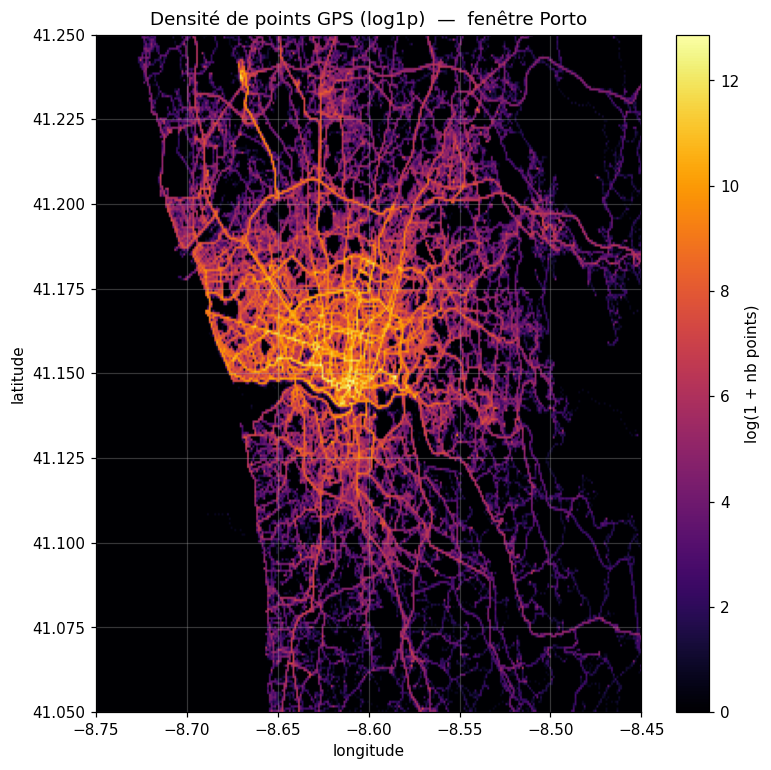

Cellules de la grille non vides : 40.5 %
Points totaux dans la fenêtre : 81,689,478


In [5]:
bb = S["bbox"]
print(f"Bounding box réel :")
print(f"  longitude ∈ [{bb['lon_min']}, {bb['lon_max']}]")
print(f"  latitude  ∈ [{bb['lat_min']}, {bb['lat_max']}]")

ext = S["grid_extent"]
lon0, lon1 = ext["lon"]; lat0, lat1 = ext["lat"]

fig, ax = plt.subplots(figsize=(8, 8))
shown = np.log1p(grid)
im = ax.imshow(shown, origin="lower", extent=[lon0, lon1, lat0, lat1],
               cmap="inferno", aspect="auto")
ax.set_title("Densité de points GPS (log1p)  —  fenêtre Porto")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
plt.colorbar(im, ax=ax, label="log(1 + nb points)")
plt.show()

covered = np.count_nonzero(grid) / grid.size
print(f"Cellules de la grille non vides : {100*covered:.1f} %")
print(f"Points totaux dans la fenêtre : {int(grid.sum()):,}")

## Axe 4 — Temporel & métadonnées

Facteurs de variation exploitables : rythmes horaires/hebdo/saisonniers, type
d'appel, stations d'origine, et concentration de l'activité par taxi.

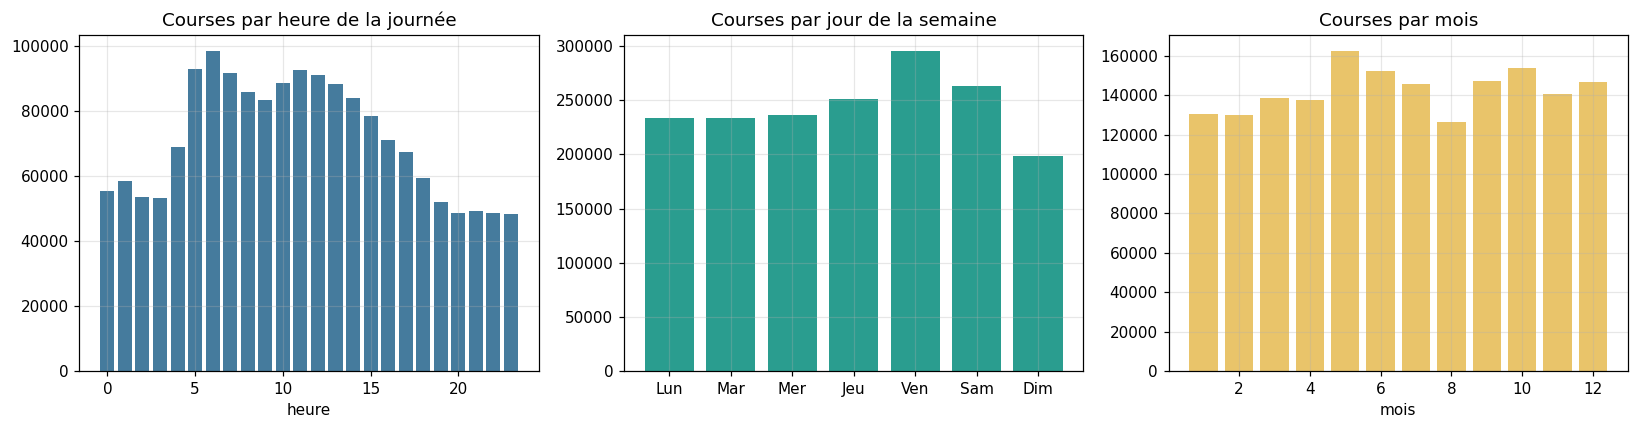

In [6]:
hour  = {int(k): v for k, v in S["hour"].items()}
dow   = {int(k): v for k, v in S["dow"].items()}
month = {int(k): v for k, v in S["month"].items()}

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
hrs = list(range(24))
ax[0].bar(hrs, [hour.get(h, 0) for h in hrs], color="#457b9d")
ax[0].set_title("Courses par heure de la journée"); ax[0].set_xlabel("heure")

names = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
ax[1].bar(names, [dow.get(d, 0) for d in range(7)], color="#2a9d8f")
ax[1].set_title("Courses par jour de la semaine")

mo = list(range(1, 13))
ax[2].bar(mo, [month.get(m, 0) for m in mo], color="#e9c46a")
ax[2].set_title("Courses par mois"); ax[2].set_xlabel("mois")
plt.tight_layout(); plt.show()

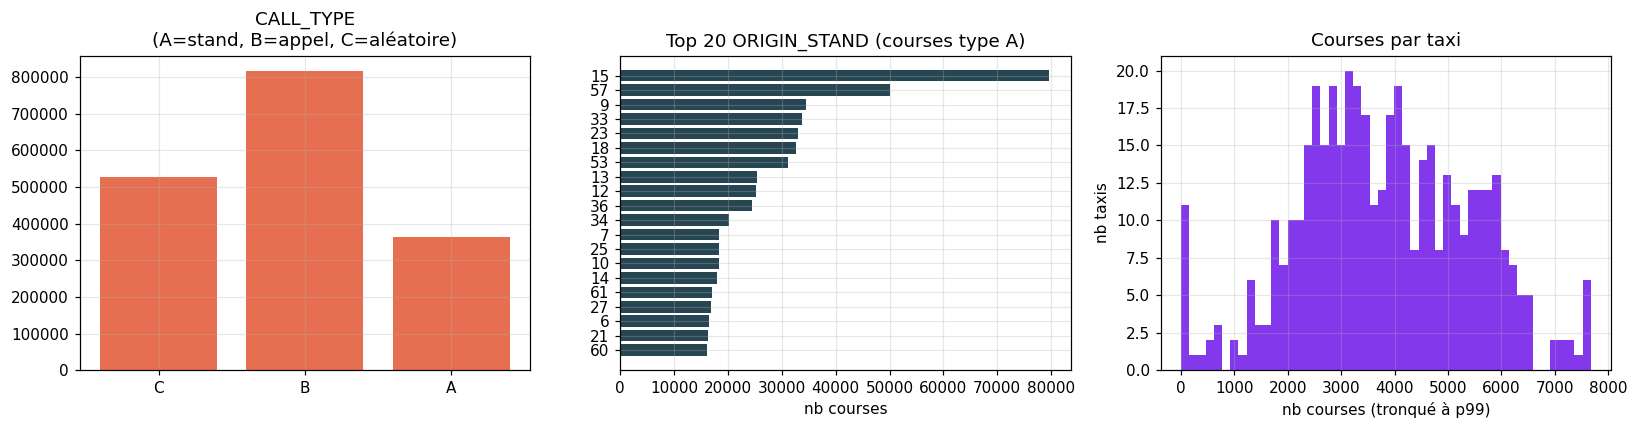

Courses par taxi : médiane=3732, max=10,746, moyenne=3818


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ct = S["call_type"]
ax[0].bar(list(ct.keys()), list(ct.values()), color="#e76f51")
ax[0].set_title("CALL_TYPE\n(A=stand, B=appel, C=aléatoire)")

stands = S["top_stands"]
ax[1].barh(list(stands.keys())[::-1], list(stands.values())[::-1], color="#264653")
ax[1].set_title("Top 20 ORIGIN_STAND (courses type A)")
ax[1].set_xlabel("nb courses")

ax[2].hist(np.clip(trips_per_taxi, 0, np.percentile(trips_per_taxi, 99)),
           bins=50, color="#8338ec")
ax[2].set_title("Courses par taxi")
ax[2].set_xlabel(f"nb courses (tronqué à p99)")
ax[2].set_ylabel("nb taxis")
plt.tight_layout(); plt.show()

print(f"Courses par taxi : médiane={np.median(trips_per_taxi):.0f}, "
      f"max={trips_per_taxi.max():,}, moyenne={trips_per_taxi.mean():.0f}")

## Axe 5 — Dynamique (vitesse, accélération, virages)

La géométrie brute ne dit rien du *mouvement*. Ici on caractérise la dynamique
segment par segment (un segment = 15 s) : vitesse instantanée, variation de
vitesse, et amplitude des virages. C'est ce qui définit la plage de dynamique
réelle et le niveau de bruit fin du signal.

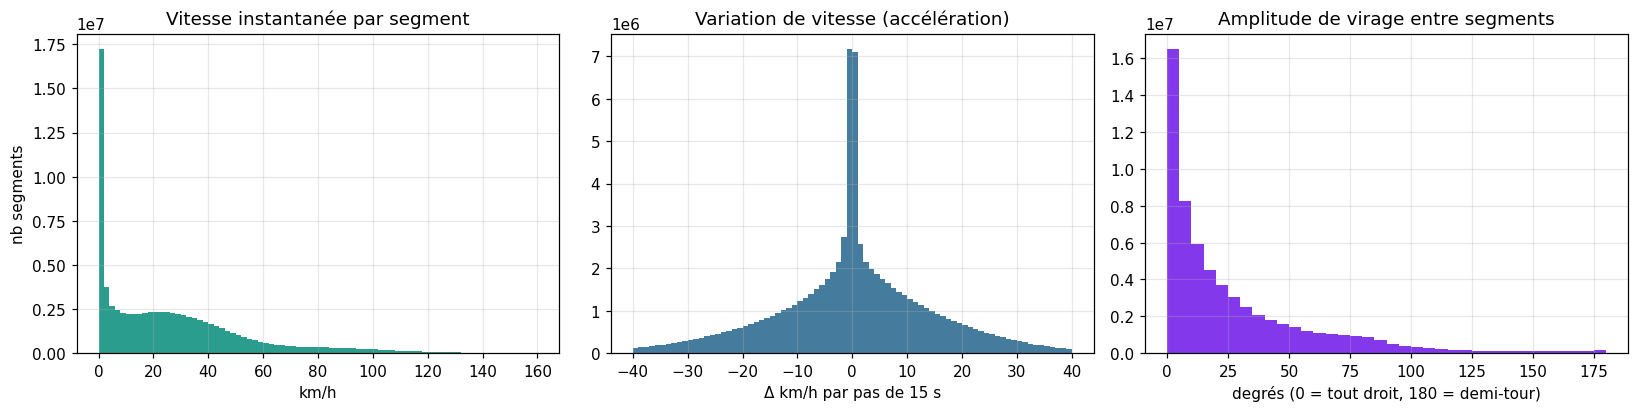

Segments analysés        : 81,704,617
  à l'arrêt (< 5 m)      : 14,290,202 (17.5 %)
  hors échelle (>160 km/h) : 171,603 (0.21 %)
Vitesse médiane par trajet : médiane des médianes = 22.0 km/h


In [8]:
speed_edges  = npz["speed_edges"];  speed_hist  = npz["speed_hist"]
acc_edges    = npz["acc_edges"];    acc_hist    = npz["acc_hist"]
angle_edges  = npz["angle_edges"];  angle_hist  = npz["angle_hist"]
med_speed    = npz["med_speed"]

def centers(edges):
    return (edges[:-1] + edges[1:]) / 2

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].bar(centers(speed_edges), speed_hist, width=np.diff(speed_edges),
          color="#2a9d8f", align="center")
ax[0].set_title("Vitesse instantanée par segment")
ax[0].set_xlabel("km/h"); ax[0].set_ylabel("nb segments")

ax[1].bar(centers(acc_edges), acc_hist, width=np.diff(acc_edges),
          color="#457b9d", align="center")
ax[1].set_title("Variation de vitesse (accélération)")
ax[1].set_xlabel("Δ km/h par pas de 15 s")

ax[2].bar(centers(angle_edges), angle_hist, width=np.diff(angle_edges),
          color="#8338ec", align="center")
ax[2].set_title("Amplitude de virage entre segments")
ax[2].set_xlabel("degrés (0 = tout droit, 180 = demi-tour)")
plt.tight_layout(); plt.show()

seg_tot = S["n_seg_total"]
print(f"Segments analysés        : {seg_tot:,}")
print(f"  à l'arrêt (< 5 m)      : {S['n_seg_stationary']:,} "
      f"({100*S['n_seg_stationary']/seg_tot:.1f} %)")
print(f"  hors échelle (>{S['speed_edges_max']:.0f} km/h) : {S['n_seg_over']:,} "
      f"({100*S['n_seg_over']/seg_tot:.2f} %)")
print(f"Vitesse médiane par trajet : médiane des médianes = "
      f"{np.median(med_speed):.1f} km/h")

## Axe 6 — Caractérisation des sauts GPS

On sait qu'une partie des trajectoires contient des segments à vitesse
irréaliste. La vraie question : est-ce **un point aberrant isolé** (pic
aller-retour, potentiellement récupérable) ou **une discontinuité franche**
(téléportation unique — typiquement un trou temporel où des points manquent) ?
Un pic isolé est un bruit local ; une discontinuité signifie que l'hypothèse
« un point toutes les 15 s » est localement fausse.

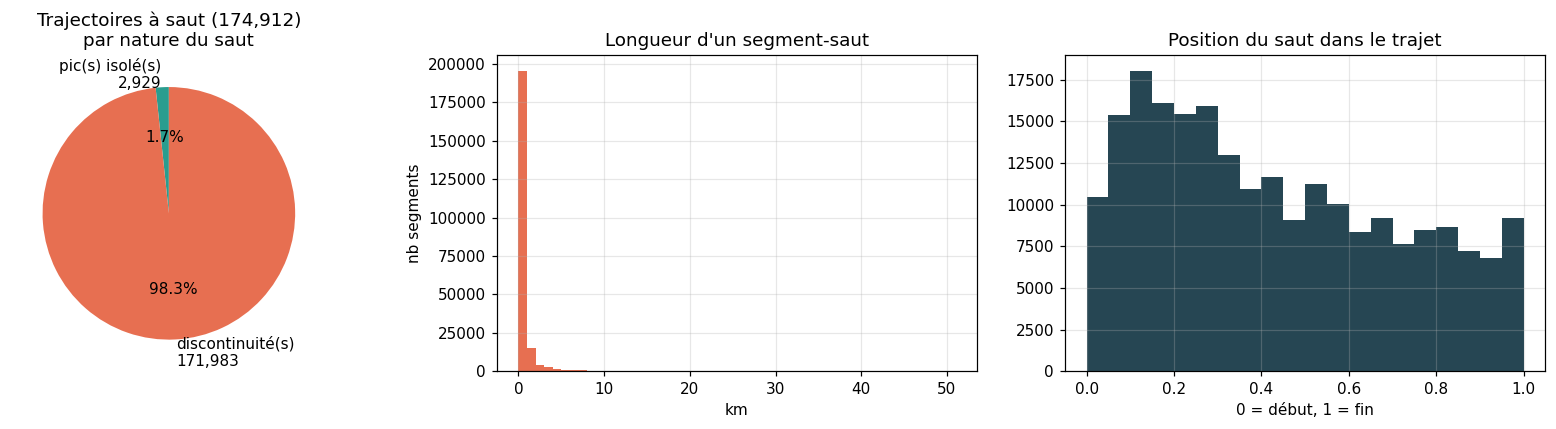

Trajectoires avec >=1 saut     : 174,912 (10.4 % du valide)
  dont pics isolés (récup.)    : 2,929 (1.7 %)
  dont >=1 discontinuité       : 171,983 (98.3 %)
Points aberrants isolés (pics) : 25,707
Segments-sauts totaux          : 223,060
  non expliqués par un pic     : 188,003 (84.3 %)


In [9]:
jd_edges = npz["jumpdist_edges"]; jd_hist = npz["jumpdist_hist"]
jp_edges = npz["jumppos_edges"]; jp_hist = npz["jumppos_hist"]

n_jump   = S["n_trips_jump"]
n_spike  = S["n_trips_spike_only"]
n_disc   = S["n_trips_discont"]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].pie([n_spike, n_disc],
          labels=[f"pic(s) isolé(s)\n{n_spike:,}", f"discontinuité(s)\n{n_disc:,}"],
          autopct="%1.1f%%", colors=["#2a9d8f", "#e76f51"], startangle=90)
ax[0].set_title(f"Trajectoires à saut ({n_jump:,})\npar nature du saut")

ax[1].bar((jd_edges[:-1] + jd_edges[1:]) / 2, jd_hist, width=np.diff(jd_edges),
          color="#e76f51", align="center")
ax[1].set_title("Longueur d'un segment-saut")
ax[1].set_xlabel("km"); ax[1].set_ylabel("nb segments")

ax[2].bar((jp_edges[:-1] + jp_edges[1:]) / 2, jp_hist, width=np.diff(jp_edges),
          color="#264653", align="center")
ax[2].set_title("Position du saut dans le trajet")
ax[2].set_xlabel("0 = début, 1 = fin")
plt.tight_layout(); plt.show()

tot = S["n_valid"]
print(f"Trajectoires avec >=1 saut     : {n_jump:,} ({100*n_jump/tot:.1f} % du valide)")
print(f"  dont pics isolés (récup.)    : {n_spike:,} ({100*n_spike/n_jump:.1f} %)")
print(f"  dont >=1 discontinuité       : {n_disc:,} ({100*n_disc/n_jump:.1f} %)")
print(f"Points aberrants isolés (pics) : {S['n_spike_points']:,}")
print(f"Segments-sauts totaux          : {S['n_jump_seg_total']:,}")
print(f"  non expliqués par un pic     : {S['n_jump_unexplained']:,} "
      f"({100*S['n_jump_unexplained']/S['n_jump_seg_total']:.1f} %)")

## Synthèse — lecture des données

Observations factuelles issues des chiffres ci-dessus (à relire après exécution
sur tes vrais résultats) :

- **Volume & propreté** : le taux de rétention et le faible nombre de sauts GPS
  indiquent si le signal est majoritairement exploitable tel quel.
- **Diversité structurelle** : l'étalement des distributions durée / distance /
  nb de points reflète la variété des trajectoires.
- **Structure spatiale** : la heatmap montre un réseau routier marqué (forte
  concentration centre-ville + axes) — c'est le type de régularité géographique
  qu'un modèle de représentation peut capter.
- **Facteurs de variation** : cycles horaires/hebdomadaires nets, types d'appel
  et stations = sources de variation labellisées, utiles pour évaluer plus tard
  ce qu'une représentation aurait capturé.
- **Dynamique** : la distribution des vitesses (pic urbain + queue), la part de
  segments à l'arrêt et le profil des virages indiquent la richesse du mouvement
  et le plancher de bruit fin.
- **Sauts GPS** : la répartition pic isolé vs discontinuité dit si les anomalies
  sont un bruit local ponctuel ou des trous temporels (hypothèse 15 s localement
  fausse) — deux natures de défaut très différentes à connaître.

Ces éléments décrivent le potentiel d'apprentissage **côté données**. Les choix
de modèle et de préparation restent entièrement de ton ressort.